# NYC Parking Violations: Analysis and Visual Story

This final notebook analyzes issued parking violations in the available
FY2025 source window (July 1, 2024 through June 30, 2025). It uses the
`parking_analysis` view so all approved borough recoveries from notebook 03
are included automatically.

## Final summary

- The analysis window contains 6,752,056 issued violations.
- October 2024 is the busiest substantially covered month, and Tuesday is the
  busiest weekday.
- Violation code 36 is the largest category with 2,186,706 tickets.
- Queens has the highest borough volume; Manhattan has the highest
  population-normalized rate.
- Borough recovery leaves only 384 in-window tickets unavailable for borough
  analysis.

Counts represent issued violations—not unique drivers, vehicles, payments, or
collected revenue.

In [1]:
from __future__ import annotations
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

**What this cell does:** Imports the analysis and visualization
libraries, sets a consistent presentation theme, and defines reusable display
formatting.

## Connect to the database

The path logic works when the notebook is launched from either the project root or the `notebooks` directory.

In [19]:
STARTING_DIR = Path.cwd()
PROJECT_ROOT = STARTING_DIR if (STARTING_DIR / "data").exists() else STARTING_DIR.parent
DATABASE_FILE = PROJECT_ROOT / "data" / "database" / "nyc_parking.sqlite"

if not DATABASE_FILE.exists():
    raise FileNotFoundError(
        f"Database not found at {DATABASE_FILE}. Run notebook 02 first."
    )

connection = sqlite3.connect(DATABASE_FILE)

has_parking_analysis = connection.execute(
    "SELECT 1 FROM sqlite_master WHERE type = 'view' AND name = 'parking_analysis'"
).fetchone()
if not has_parking_analysis:
    connection.close()
    raise RuntimeError(
        "The parking_analysis view is missing. Run notebook 03 before notebook 04."
    )

FY_START = "2024-07-01"
FY_END = "2025-06-30"
print(f"Database: {DATABASE_FILE}")
print(f"Analysis window: {FY_START} through {FY_END}")

Database: c:\Users\jayson.coker\Documents\nyc-parking-analytics\data\database\nyc_parking.sqlite
Analysis window: 2024-07-01 through 2025-06-30


**Result:** The analysis connects to the generated SQLite database
and applies one explicit FY2025 window to every final query.

## Data-quality check

The source is labeled fiscal year 2025, but administrative files can contain corrected, late, or invalid dates. This check reports how many rows fall inside and outside the intended analysis window. A later monthly coverage check prevents months with only a few records from being treated as complete.

In [3]:
date_quality = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN issue_date BETWEEN ? AND ? THEN 1 ELSE 0 END) AS fy2025_rows,
        SUM(CASE WHEN issue_date < ? OR issue_date > ? THEN 1 ELSE 0 END) AS excluded_date_rows,
        MIN(issue_date) AS earliest_issue_date,
        MAX(issue_date) AS latest_issue_date
    FROM parking_violations
    """,
    connection,
    params=(FY_START, FY_END, FY_START, FY_END),
)
date_quality

,total_rows,fy2025_rows,excluded_date_rows,earliest_issue_date,latest_issue_date
0,7056788,6752056,304732,2000-06-03,2025-12-01


**Result:** Of 7,056,788 cleaned tickets, 6,752,056 fall inside the
analysis window. The 304,732 excluded rows remain in the database but are not
mixed into FY2025 conclusions.

## 1. Monthly ticket trend

A line chart makes changes over time easy to see. The SQL query aggregates millions of ticket rows into twelve monthly totals before Pandas receives the data.

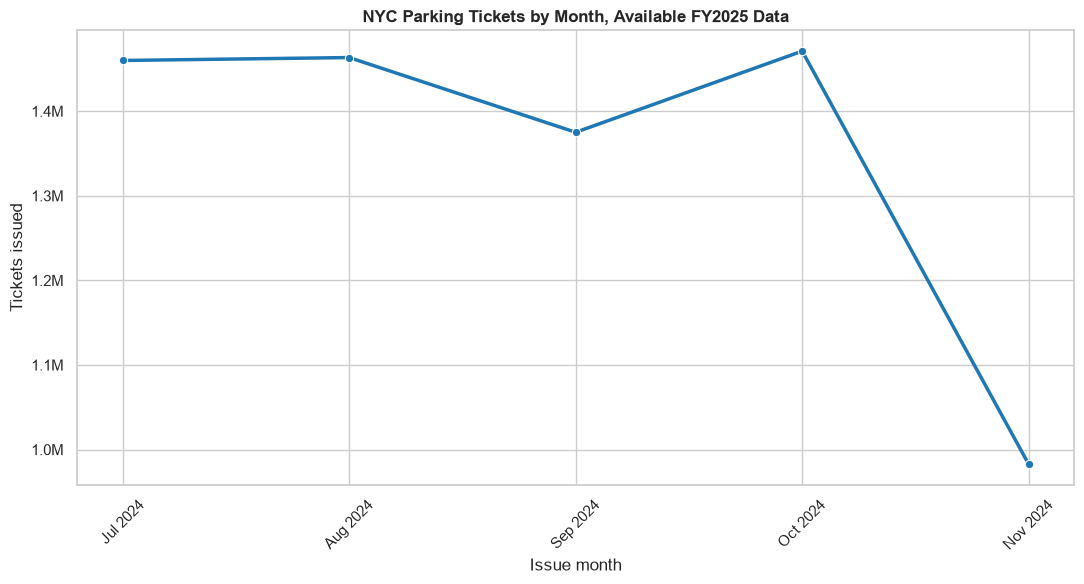

Finding: Oct 2024 had the most tickets (1,470,983), while Nov 2024 had the fewest among months with substantial coverage (982,608).
Coverage note: months with fewer than 500 records were excluded from the comparison: Dec 2024, Jan 2025, Feb 2025, Mar 2025, May 2025, Jun 2025


In [4]:
monthly_tickets = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', issue_date) AS issue_month,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    GROUP BY strftime('%Y-%m', issue_date)
    ORDER BY issue_month
    """,
    connection,
    params=(FY_START, FY_END),
)
monthly_tickets["month_label"] = pd.to_datetime(
    monthly_tickets["issue_month"]
).dt.strftime("%b %Y")
complete_months = monthly_tickets[monthly_tickets["ticket_count"] >= 500].copy()
sparse_months = monthly_tickets[monthly_tickets["ticket_count"] < 500].copy()

ax = sns.lineplot(
    data=complete_months,
    x="month_label",
    y="ticket_count",
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
)
ax.set(
    title="NYC Parking Tickets by Month, Available FY2025 Data",
    xlabel="Issue month",
    ylabel="Tickets issued",
)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
plt.tight_layout()
plt.show()

peak_month = complete_months.loc[complete_months["ticket_count"].idxmax()]
low_month = complete_months.loc[complete_months["ticket_count"].idxmin()]
print(
    f"Finding: {peak_month['month_label']} had the most tickets "
    f"({peak_month['ticket_count']:,}), while {low_month['month_label']} "
    f"had the fewest among months with substantial coverage "
    f"({low_month['ticket_count']:,})."
)
print(
    "Coverage note: months with fewer than 500 records were excluded from "
    "the comparison: "
    + ", ".join(sparse_months["month_label"])
)

**Interpretation:** October 2024 leads the substantially covered
months with 1,470,983 tickets. Months with fewer than 500 records are treated
as incomplete coverage, not an enforcement collapse.

## 2. Most common violation types

This query joins the parking fact table to the violation lookup dimension. A horizontal bar chart leaves enough room for the violation descriptions.

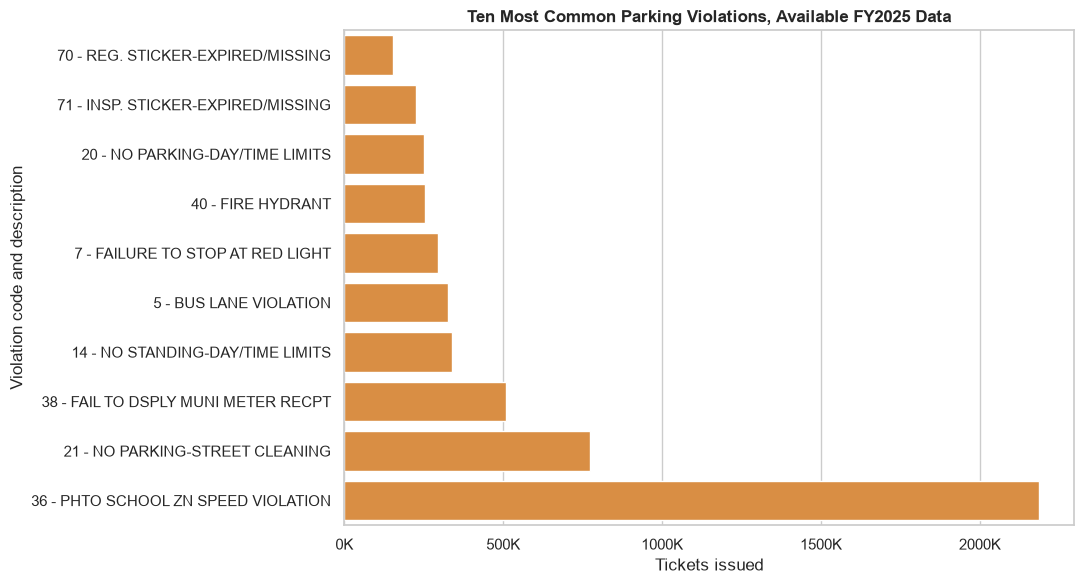

Finding: violation code 36 was the most common with 2,186,706 tickets. The top ten codes together accounted for 78.6% of in-window tickets.


In [5]:
top_violations = pd.read_sql_query(
    """
    SELECT
        p.violation_code,
        COALESCE(v.violation_description, 'Description unavailable') AS violation_description,
        COUNT(*) AS ticket_count
    FROM parking_violations AS p
    LEFT JOIN violation_lookup AS v
        ON v.violation_code = p.violation_code
    WHERE p.issue_date BETWEEN ? AND ?
    GROUP BY p.violation_code, v.violation_description
    ORDER BY ticket_count DESC
    LIMIT 10
    """,
    connection,
    params=(FY_START, FY_END),
)
top_violations["label"] = (
    top_violations["violation_code"].astype("Int64").astype(str)
    + " - "
    + top_violations["violation_description"].str.slice(0, 48)
)

plot_data = top_violations.sort_values("ticket_count")
ax = sns.barplot(
    data=plot_data,
    x="ticket_count",
    y="label",
    color="#f28e2b",
)
ax.set(
    title="Ten Most Common Parking Violations, Available FY2025 Data",
    xlabel="Tickets issued",
    ylabel="Violation code and description",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

leader = top_violations.iloc[0]
top_share = top_violations["ticket_count"].sum() / date_quality.loc[0, "fy2025_rows"]
print(
    f"Finding: violation code {int(leader['violation_code'])} was the most common "
    f"with {leader['ticket_count']:,} tickets. The top ten codes together "
    f"accounted for {top_share:.1%} of in-window tickets."
)

**Interpretation:** Code 36 is the dominant violation with 2,186,706
tickets. The top ten categories represent 78.6% of all in-window records.

## 3. Month and weekday pattern

The heatmap compares two time dimensions at once. Each cell shows the number of tickets issued for a weekday during a fiscal-year month.

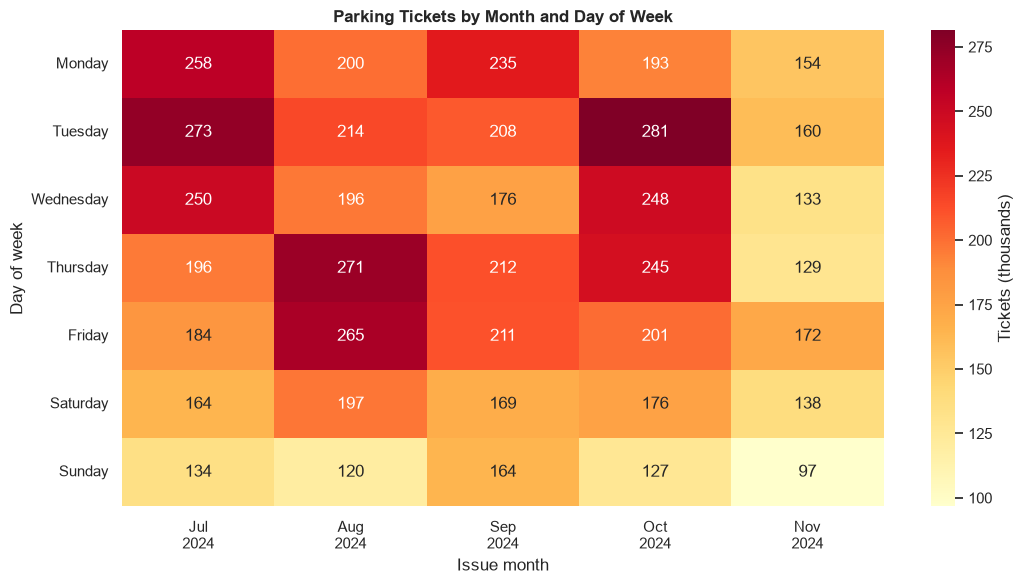

Finding: Tuesday had the highest total ticket volume, while Sunday had the lowest.


In [6]:
weekday_month = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', issue_date) AS issue_month,
        issue_day_of_week,
        issue_day_name,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    GROUP BY strftime('%Y-%m', issue_date), issue_day_of_week, issue_day_name
    ORDER BY issue_month, issue_day_of_week
    """,
    connection,
    params=(FY_START, FY_END),
)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = complete_months["issue_month"].tolist()
heatmap_data = weekday_month.pivot_table(
    index="issue_day_name",
    columns="issue_month",
    values="ticket_count",
    aggfunc="sum",
).reindex(index=weekday_order, columns=month_order)
heatmap_data.columns = pd.to_datetime(heatmap_data.columns).strftime("%b\n%Y")

ax = sns.heatmap(
    heatmap_data / 1_000,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Tickets (thousands)"},
)
ax.set(
    title="Parking Tickets by Month and Day of Week",
    xlabel="Issue month",
    ylabel="Day of week",
)
plt.tight_layout()
plt.show()

weekday_totals = weekday_month.groupby("issue_day_name")["ticket_count"].sum()
busiest_day = weekday_totals.idxmax()
quietest_day = weekday_totals.idxmin()
print(
    f"Finding: {busiest_day} had the highest total ticket volume, while "
    f"{quietest_day} had the lowest."
)

**Interpretation:** Tuesday has the highest ticket volume and Sunday
the lowest. The heatmap shows both the weekday pattern and the uneven monthly
source coverage.

## 4. Vehicle attributes and similarities

The parking source contains `vehicle_make`, `vehicle_color`, `vehicle_year`, and `vehicle_body_type`. It does **not** contain a vehicle model field, so this analysis does not infer models from the other attributes.

Vehicle makes and body types are administrative abbreviations such as `TOYOT` for Toyota and `SUBN` for suburban/SUV. Colors appear as both codes and words, so common values are standardized before comparison.

In [7]:
vehicle_completeness = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS ticket_rows,
        SUM(CASE WHEN vehicle_make IS NOT NULL AND TRIM(vehicle_make) <> '' THEN 1 ELSE 0 END) AS rows_with_make,
        SUM(CASE WHEN vehicle_color IS NOT NULL AND TRIM(vehicle_color) <> '' THEN 1 ELSE 0 END) AS rows_with_color,
        SUM(CASE WHEN vehicle_year BETWEEN 1980 AND 2025 THEN 1 ELSE 0 END) AS rows_with_valid_year,
        SUM(CASE WHEN vehicle_body_type IS NOT NULL AND TRIM(vehicle_body_type) <> '' THEN 1 ELSE 0 END) AS rows_with_body_type
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    """,
    connection,
    params=(FY_START, FY_END),
)
vehicle_completeness

,ticket_rows,rows_with_make,rows_with_color,rows_with_valid_year,rows_with_body_type
0,6752056,6745545,6081928,5566160,6735913


**Result:** Make and body type are nearly complete, color is
available for about 90% of rows, and 5,566,160 records contain a plausible
1980–2025 vehicle year. Later vehicle charts use only appropriate non-null
subsets.

### Most common vehicle makes

This chart counts ticket records, not unique vehicles. A vehicle can appear more than once if it received multiple tickets.

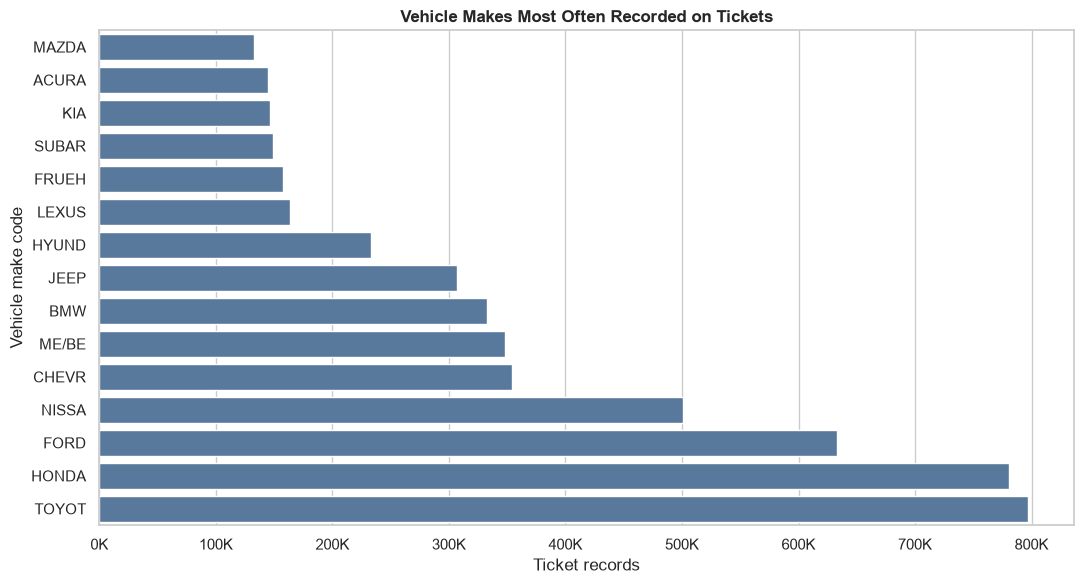

Finding: TOYOT was the most frequently recorded make, appearing on 796,594 tickets.


In [8]:
top_makes = pd.read_sql_query(
    """
    SELECT vehicle_make, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IS NOT NULL
      AND TRIM(vehicle_make) <> ''
    GROUP BY vehicle_make
    ORDER BY ticket_count DESC
    LIMIT 15
    """,
    connection,
    params=(FY_START, FY_END),
)

ax = sns.barplot(
    data=top_makes.sort_values("ticket_count"),
    x="ticket_count",
    y="vehicle_make",
    color="#4e79a7",
)
ax.set(
    title="Vehicle Makes Most Often Recorded on Tickets",
    xlabel="Ticket records",
    ylabel="Vehicle make code",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

print(
    f"Finding: {top_makes.iloc[0]['vehicle_make']} was the most frequently "
    f"recorded make, appearing on {top_makes.iloc[0]['ticket_count']:,} tickets."
)

**Interpretation:** `TOYOT` is the most frequently recorded make,
appearing on 796,594 tickets. The source uses abbreviated make codes, so the
chart preserves those recorded values.

### Standardized vehicle colors

The same color can be entered several ways. For example, `GY`, `GREY`, `GRAY`, and `GRY` are grouped as Gray. Less common or ambiguous codes remain in Other.

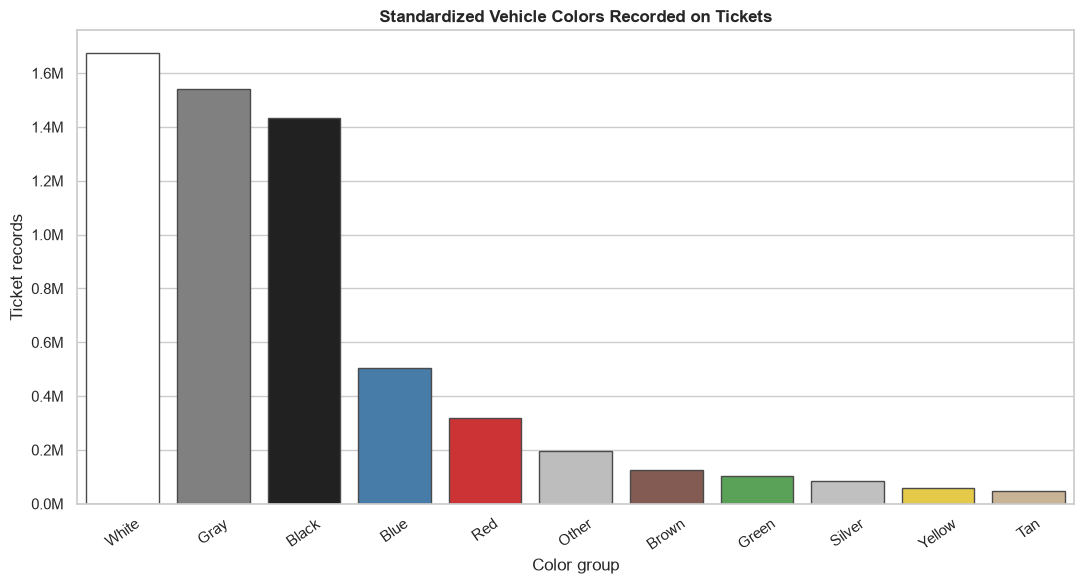

In [20]:
color_case = """
    CASE UPPER(TRIM(vehicle_color))
        WHEN 'GY' THEN 'Gray' WHEN 'GREY' THEN 'Gray' WHEN 'GRAY' THEN 'Gray' WHEN 'GRY' THEN 'Gray'
        WHEN 'WH' THEN 'White' WHEN 'WHITE' THEN 'White' WHEN 'WHI' THEN 'White'
        WHEN 'BK' THEN 'Black' WHEN 'BLACK' THEN 'Black' WHEN 'BLK' THEN 'Black'
        WHEN 'BL' THEN 'Blue' WHEN 'BLUE' THEN 'Blue'
        WHEN 'RD' THEN 'Red' WHEN 'RED' THEN 'Red'
        WHEN 'BR' THEN 'Brown' WHEN 'BROWN' THEN 'Brown'
        WHEN 'GR' THEN 'Green' WHEN 'GREEN' THEN 'Green'
        WHEN 'SILVE' THEN 'Silver' WHEN 'SILVER' THEN 'Silver' WHEN 'SL' THEN 'Silver'
        WHEN 'YW' THEN 'Yellow' WHEN 'YELLOW' THEN 'Yellow' WHEN 'YELLO' THEN 'Yellow'
        WHEN 'TN' THEN 'Tan' WHEN 'TAN' THEN 'Tan'
        ELSE 'Other'
    END
"""

vehicle_colors = pd.read_sql_query(
    f"""
    SELECT {color_case} AS vehicle_color_group, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_color IS NOT NULL
      AND TRIM(vehicle_color) <> ''
    GROUP BY vehicle_color_group
    ORDER BY ticket_count DESC
    """,
    connection,
    params=(FY_START, FY_END),
)

vehicle_color_palette = {
    "Gray": "#808080",
    "White": "#FFFFFF",
    "Black": "#212121",
    "Blue": "#377EB8",
    "Red": "#E41A1C",
    "Brown": "#8C564B",
    "Green": "#4DAF4A",
    "Silver": "#C0C0C0",
    "Yellow": "#FFD92F",
    "Tan": "#D2B48C",
    "Other": "#BDBDBD",
}

ax = sns.barplot(
    data=vehicle_colors,
    x="vehicle_color_group",
    y="ticket_count",
    hue="vehicle_color_group",
    palette=vehicle_color_palette,
    legend=False,
    edgecolor="#4A4A4A",
)
ax.set(
    title="Standardized Vehicle Colors Recorded on Tickets",
    xlabel="Color group",
    ylabel="Ticket records",
)
ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
plt.tight_layout()
plt.show()

**Interpretation:** Standardizing common abbreviations prevents
values such as `GY`, `GRAY`, and `GREY` from being counted as separate colors;
unrecognized values remain grouped as `Other`.

### Vehicle model years

A value of zero is common in the source and means the year was unavailable, so only plausible years from 1980 through 2025 are charted.

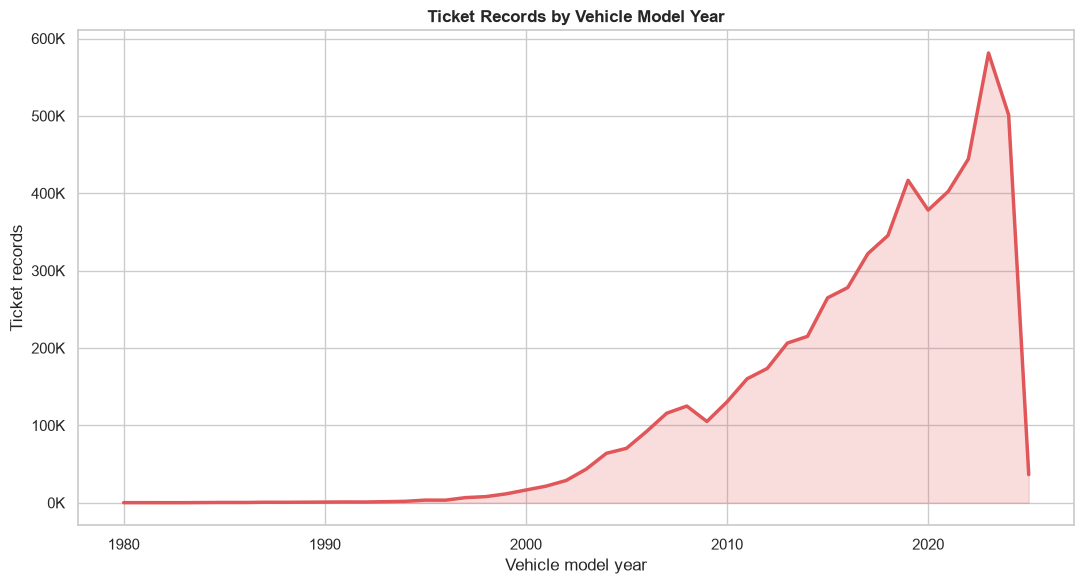

Finding: model year 2023 appeared most often among records with plausible years (581,323 tickets).


In [ ]:
vehicle_years = pd.read_sql_query(
    """
    SELECT vehicle_year, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_year BETWEEN 1980 AND 2025
    GROUP BY vehicle_year
    ORDER BY vehicle_year
    """,
    connection,
    params=(FY_START, FY_END),
)

ax = sns.lineplot(
    data=vehicle_years,
    x="vehicle_year",
    y="ticket_count",
    color="#e15759",
    linewidth=2.5,
)
ax.fill_between(
    vehicle_years["vehicle_year"],
    vehicle_years["ticket_count"],
    alpha=0.2,
    color="#e15759",
)
ax.set(
    title="Ticket Records by Vehicle Model Year",
    xlabel="Vehicle model year",
    ylabel="Ticket records",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

peak_year = vehicle_years.loc[vehicle_years["ticket_count"].idxmax()]
print(
    f"Finding: model year {int(peak_year['vehicle_year'])} appeared most often " # type: ignore
    f"among records with plausible years ({peak_year['ticket_count']:,} tickets)."
)

**Interpretation:** Model year 2023 is the most common plausible year
with 581,323 ticket records. The distribution describes ticket records, not
the overall NYC vehicle fleet.

### Similarities between make and color

The heatmap shows which standardized colors occur most often for the eight most frequently ticketed makes. Values are ticket records in thousands.

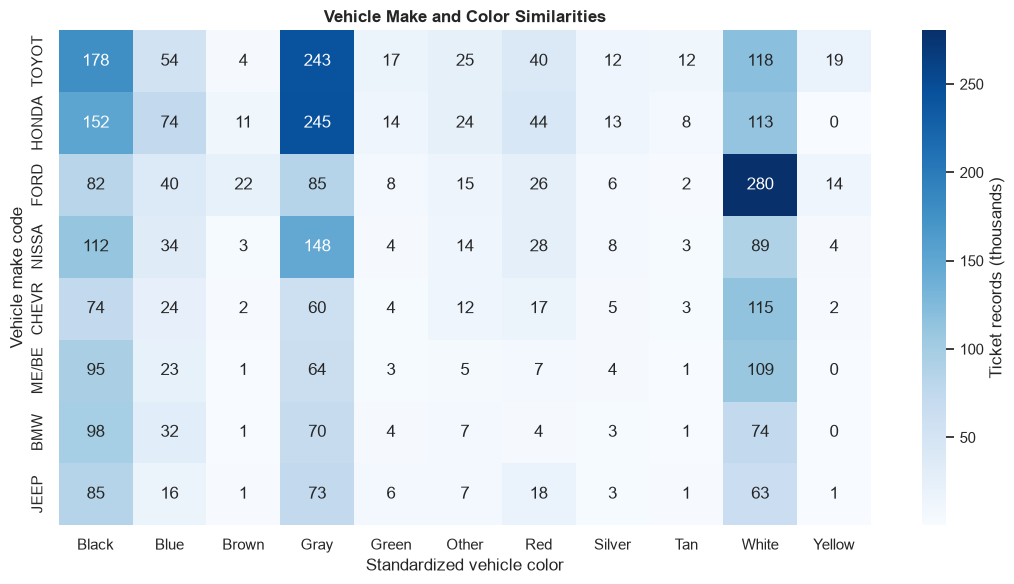

In [11]:
top_make_list = top_makes.head(8)["vehicle_make"].tolist()
placeholders = ", ".join("?" for _ in top_make_list)
make_color = pd.read_sql_query(
    f"""
    SELECT
        vehicle_make,
        {color_case} AS vehicle_color_group,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IN ({placeholders})
      AND vehicle_color IS NOT NULL
      AND TRIM(vehicle_color) <> ''
    GROUP BY vehicle_make, vehicle_color_group
    """,
    connection,
    params=(FY_START, FY_END, *top_make_list),
)
make_color_matrix = make_color.pivot_table(
    index="vehicle_make",
    columns="vehicle_color_group",
    values="ticket_count",
    aggfunc="sum",
    fill_value=0,
).reindex(top_make_list)

ax = sns.heatmap(
    make_color_matrix / 1_000,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Ticket records (thousands)"},
)
ax.set(
    title="Vehicle Make and Color Similarities",
    xlabel="Standardized vehicle color",
    ylabel="Vehicle make code",
)
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap compares color patterns within the
eight most frequently ticketed make codes. It highlights combinations without
claiming that make or color causes violations.

### Most common combined vehicle profiles

This final table combines make, standardized color, plausible model year, and body type. It is the closest available view to a make/model/color/year profile because the source does not include model.

In [12]:
vehicle_profiles = pd.read_sql_query(
    f"""
    SELECT
        vehicle_make,
        {color_case} AS vehicle_color_group,
        vehicle_year,
        vehicle_body_type,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IS NOT NULL
      AND vehicle_color IS NOT NULL
      AND vehicle_year BETWEEN 1980 AND 2025
      AND vehicle_body_type IS NOT NULL
    GROUP BY vehicle_make, vehicle_color_group, vehicle_year, vehicle_body_type
    ORDER BY ticket_count DESC
    LIMIT 25
    """,
    connection,
    params=(FY_START, FY_END),
)
vehicle_profiles

,vehicle_make,vehicle_color_group,vehicle_year,vehicle_body_type,ticket_count
0,FORD,White,2023,VAN,16133
1,FORD,White,2019,VAN,12064
2,TOYOT,Gray,2021,SUBN,11958
3,FORD,White,2020,VAN,11876
4,FORD,White,2017,VAN,11808
5,HONDA,Gray,2024,SUBN,11079
6,TOYOT,Gray,2022,SUBN,10701
7,HONDA,Gray,2022,SUBN,10638
8,TOYOT,Gray,2023,SUBN,10606
9,TESLA,Black,2023,SUBN,10020


**Result:** The most frequent complete profile is a white 2023 Ford
van with 16,133 ticket records. These are recurring attribute combinations,
not necessarily unique vehicles.

## 5. Borough recovery coverage

Before using boroughs, this check reconciles the fiscal-year rows by source.
`original` values came from the cleaned parking data, `recovered` values came
from the audited notebook 03 workflow, and `missing` values remain excluded
from borough comparisons.

In [13]:
borough_source_quality = pd.read_sql_query(
    """
    SELECT
        borough_source,
        COUNT(*) AS ticket_count
    FROM parking_analysis
    WHERE issue_date BETWEEN ? AND ?
    GROUP BY borough_source
    ORDER BY ticket_count DESC
    """,
    connection,
    params=(FY_START, FY_END),
)

borough_source_quality["share_pct"] = (
    100 * borough_source_quality["ticket_count"]
    / borough_source_quality["ticket_count"].sum()
)
assert borough_source_quality["ticket_count"].sum() == date_quality.loc[
    0, "fy2025_rows"
]

display(borough_source_quality)

recovered_count = int(
    borough_source_quality.loc[
        borough_source_quality["borough_source"].eq("recovered"),
        "ticket_count",
    ].sum()
)
missing_count = int(
    borough_source_quality.loc[
        borough_source_quality["borough_source"].eq("missing"),
        "ticket_count",
    ].sum()
)
print(
    f"Coverage finding: {recovered_count:,} fiscal-year rows use an audited "
    f"borough recovery; {missing_count:,} remain unavailable for borough analysis."
)

,borough_source,ticket_count,share_pct
0,original,6601050,97.763555
1,recovered,150622,2.230758
2,missing,384,0.005687


Coverage finding: 150,622 fiscal-year rows use an audited borough recovery; 384 remain unavailable for borough analysis.


**Result:** Original boroughs cover 97.76% of FY2025 rows, audited
recoveries add 150,622 rows (2.23%), and only 384 rows (0.006%) remain missing.

## 6. Ticket volume by borough

A sorted horizontal bar chart compares the number of issued violations across
the five boroughs. Counts represent tickets, not unique vehicles or drivers.
The query uses both original and approved recovered borough values.

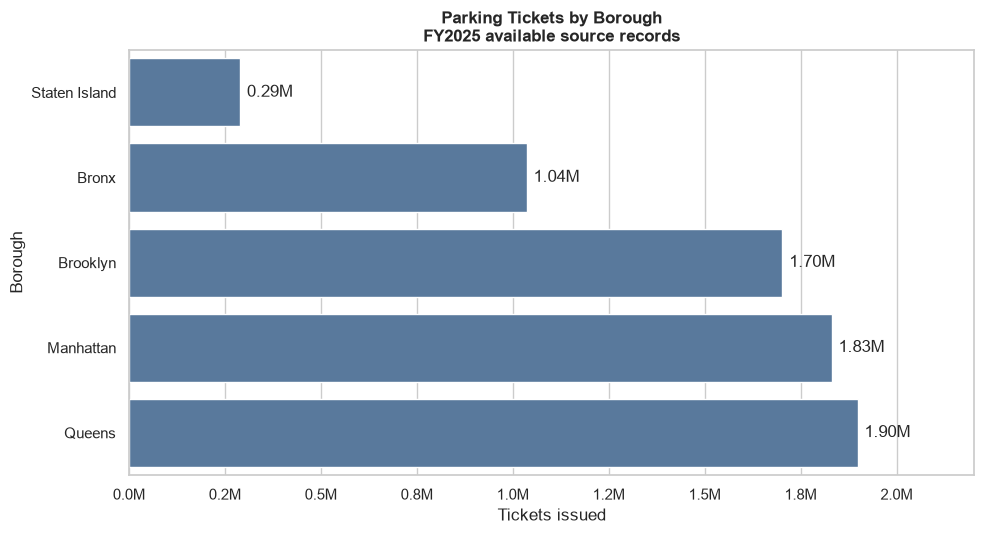

,borough,ticket_count,recovered_count,recovered_share_pct
0,Queens,1897298,4244,0.223687
1,Manhattan,1829790,31497,1.721345
2,Brooklyn,1701380,4242,0.249327
3,Bronx,1035070,107357,10.371956
4,Staten Island,288134,3282,1.139053


Finding: Queens had the largest ticket volume (1,897,298 issued violations).


In [ ]:
borough_volume = pd.read_sql_query(
    """
    SELECT
        analysis_borough AS borough,
        COUNT(*) AS ticket_count,
        SUM(CASE WHEN borough_source = 'recovered' THEN 1 ELSE 0 END)
            AS recovered_count
    FROM parking_analysis
    WHERE issue_date BETWEEN ? AND ?
      AND analysis_borough IS NOT NULL
    GROUP BY analysis_borough
    ORDER BY ticket_count DESC
    """,
    connection,
    params=(FY_START, FY_END),
)
borough_volume["recovered_share_pct"] = (
    100 * borough_volume["recovered_count"] / borough_volume["ticket_count"]
)

plot_data = borough_volume.sort_values("ticket_count")
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_data,
    x="ticket_count",
    y="borough",
    color="#4E79A7",
    ax=ax,
)
ax.set(
    title="Parking Tickets by Borough\nFY2025 available source records",
    xlabel="Tickets issued",
    ylabel="Borough",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
ax.set_xlim(0, plot_data["ticket_count"].max() * 1.16)
ax.bar_label(
    ax.containers[0], # pyright: ignore[reportArgumentType]
    labels=[f"{value / 1_000_000:.2f}M" for value in plot_data["ticket_count"]],
    padding=5,
)
plt.tight_layout()
plt.show()

display(borough_volume)
volume_leader = borough_volume.iloc[0]
print(
    f"Finding: {volume_leader['borough']} had the largest ticket volume "
    f"({volume_leader['ticket_count']:,} issued violations)."
)

**Interpretation:** Queens has the largest borough volume at
1,897,298 tickets. The recovered share is largest in the Bronx, where recovery
materially improves location completeness.

## 7. Leading violation mix by borough

Raw totals mostly reflect borough size and enforcement volume. This heatmap
instead shows each violation code as a percentage of that borough's tickets,
which makes the mix comparable across boroughs. The columns are the six most
common codes citywide during the analysis window.

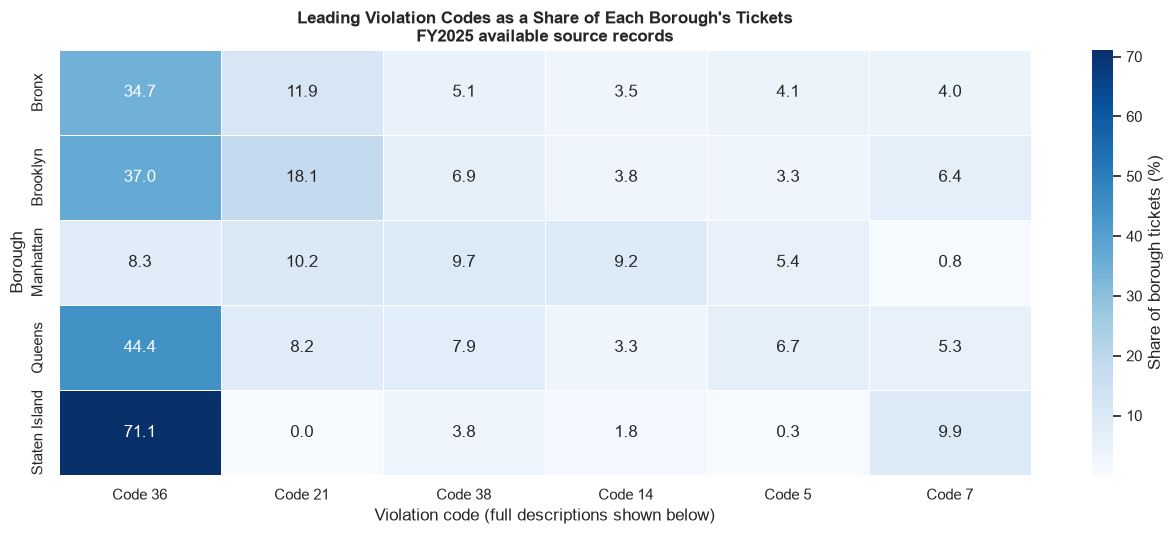

,violation_code,violation_description
0,36,PHTO SCHOOL ZN SPEED VIOLATION
1,21,NO PARKING-STREET CLEANING
2,38,FAIL TO DSPLY MUNI METER RECPT
3,14,NO STANDING-DAY/TIME LIMITS
4,5,BUS LANE VIOLATION
5,7,FAILURE TO STOP AT RED LIGHT


,borough,violation_code,violation_description,borough_share_pct
0,Bronx,36,PHTO SCHOOL ZN SPEED VIOLATION,34.673790
1,Brooklyn,36,PHTO SCHOOL ZN SPEED VIOLATION,36.951298
7,Manhattan,21,NO PARKING-STREET CLEANING,10.153624
3,Queens,36,PHTO SCHOOL ZN SPEED VIOLATION,44.370415
4,Staten Island,36,PHTO SCHOOL ZN SPEED VIOLATION,71.123158


Finding: the leading violation category and its concentration vary by borough; the percentage scale avoids mistaking borough size for violation mix.


In [15]:
borough_violation_mix = pd.read_sql_query(
    """
    WITH top_codes AS (
        SELECT violation_code, COUNT(*) AS citywide_count
        FROM parking_analysis
        WHERE issue_date BETWEEN ? AND ?
          AND analysis_borough IS NOT NULL
        GROUP BY violation_code
        ORDER BY citywide_count DESC
        LIMIT 6
    ),
    borough_totals AS (
        SELECT analysis_borough AS borough, COUNT(*) AS borough_total
        FROM parking_analysis
        WHERE issue_date BETWEEN ? AND ?
          AND analysis_borough IS NOT NULL
        GROUP BY analysis_borough
    )
    SELECT
        p.analysis_borough AS borough,
        p.violation_code,
        COALESCE(v.violation_description, 'Description unavailable')
            AS violation_description,
        COUNT(*) AS ticket_count,
        b.borough_total,
        100.0 * COUNT(*) / b.borough_total AS borough_share_pct
    FROM parking_analysis AS p
    INNER JOIN top_codes AS t
        ON t.violation_code = p.violation_code
    INNER JOIN borough_totals AS b
        ON b.borough = p.analysis_borough
    LEFT JOIN violation_lookup AS v
        ON v.violation_code = p.violation_code
    WHERE p.issue_date BETWEEN ? AND ?
      AND p.analysis_borough IS NOT NULL
    GROUP BY
        p.analysis_borough,
        p.violation_code,
        v.violation_description,
        b.borough_total
    ORDER BY t.citywide_count DESC, p.analysis_borough
    """,
    connection,
    params=(FY_START, FY_END, FY_START, FY_END, FY_START, FY_END),
)

borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
code_order = (
    borough_violation_mix.groupby("violation_code")["ticket_count"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)
heatmap_data = borough_violation_mix.pivot(
    index="borough",
    columns="violation_code",
    values="borough_share_pct",
).reindex(index=borough_order, columns=code_order)

code_descriptions = (
    borough_violation_mix[["violation_code", "violation_description"]]
    .drop_duplicates("violation_code")
    .set_index("violation_code")["violation_description"]
)
column_labels = [f"Code {code}" for code in code_order]
code_key = (
    code_descriptions.reindex(code_order)
    .rename_axis("violation_code")
    .reset_index(name="violation_description")
)

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    cbar_kws={"label": "Share of borough tickets (%)"},
    ax=ax,
)
ax.set(
    title="Leading Violation Codes as a Share of Each Borough's Tickets\nFY2025 available source records",
    xlabel="Violation code (full descriptions shown below)",
    ylabel="Borough",
)
ax.set_xticklabels(column_labels, rotation=0)
plt.tight_layout()
plt.show()

borough_leaders = (
    borough_violation_mix.sort_values("borough_share_pct", ascending=False)
    .drop_duplicates("borough")
    [["borough", "violation_code", "violation_description", "borough_share_pct"]]
    .sort_values("borough")
)
display(code_key)
display(borough_leaders)
print(
    "Finding: the leading violation category and its concentration vary by borough; "
    "the percentage scale avoids mistaking borough size for violation mix."
)

**Interpretation:** Code 36 leads four boroughs and reaches 71.1% in
Staten Island; Manhattan differs, with code 21 leading at 10.2%. Percentages
allow fair comparison despite different borough totals.

## 8. Population-normalized borough comparison

Ticket totals are divided by Census Vintage 2025 population estimates to
provide geographic context. This rate is **issued violations per 1,000
residents**, not a measure of resident behavior: tickets can be issued to
commuters, visitors, commercial vehicles, and repeat vehicles.

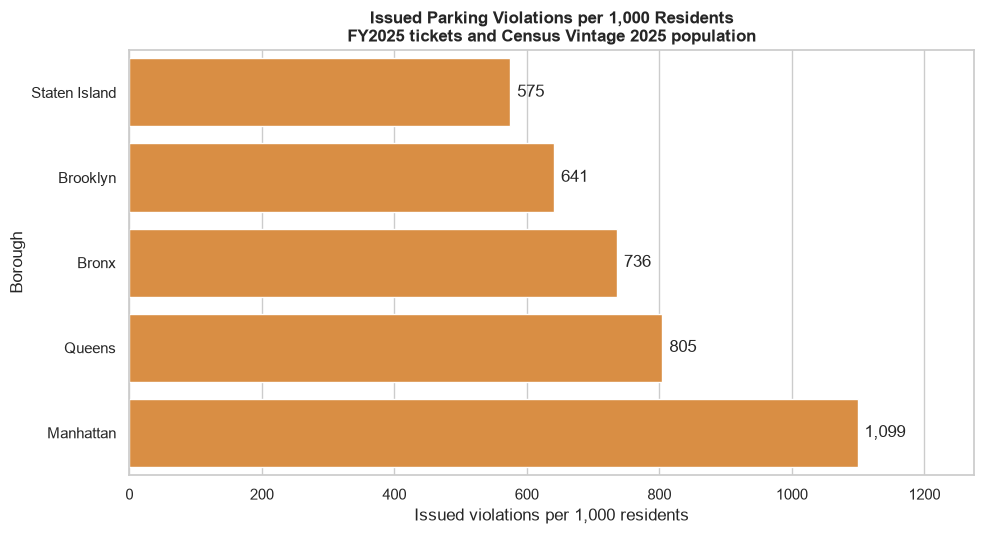

,borough,population,census_year,ticket_count,tickets_per_1000_residents
0,Manhattan,1664862,2025,1829790,1099.064067
1,Queens,2358182,2025,1897298,804.559614
2,Bronx,1406332,2025,1035070,736.006860
3,Brooklyn,2653963,2025,1701380,641.071484
4,Staten Island,501290,2025,288134,574.785055


Finding: Manhattan had the highest population-normalized rate (1,099 issued violations per 1,000 residents).


In [ ]:
borough_population_rate = pd.read_sql_query(
    """
    SELECT
        p.analysis_borough AS borough,
        c.population,
        c.census_year,
        COUNT(*) AS ticket_count,
        1000.0 * COUNT(*) / c.population AS tickets_per_1000_residents
    FROM parking_analysis AS p
    INNER JOIN census_borough AS c
        ON c.borough = p.analysis_borough
    WHERE p.issue_date BETWEEN ? AND ?
    GROUP BY p.analysis_borough, c.population, c.census_year
    ORDER BY tickets_per_1000_residents DESC
    """,
    connection,
    params=(FY_START, FY_END),
)

plot_data = borough_population_rate.sort_values("tickets_per_1000_residents")
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_data,
    x="tickets_per_1000_residents",
    y="borough",
    color="#F28E2B",
    ax=ax,
)
ax.set(
    title="Issued Parking Violations per 1,000 Residents\nFY2025 tickets and Census Vintage 2025 population",
    xlabel="Issued violations per 1,000 residents",
    ylabel="Borough",
)
ax.set_xlim(0, plot_data["tickets_per_1000_residents"].max() * 1.16)
ax.bar_label(
    ax.containers[0], # type: ignore
    labels=[f"{value:,.0f}" for value in plot_data["tickets_per_1000_residents"]],
    padding=5,
)
plt.tight_layout()
plt.show()

display(borough_population_rate)
rate_leader = borough_population_rate.iloc[0]
print(
    f"Finding: {rate_leader['borough']} had the highest population-normalized "
    f"rate ({rate_leader['tickets_per_1000_residents']:,.0f} issued violations "
    "per 1,000 residents)."
)

**Interpretation:** Manhattan has the highest population-normalized
rate at 1,099 issued violations per 1,000 residents. This is an exposure and
enforcement context measure, not a rate of resident offending.

## Conclusions

- The available FY2025 window contains 6,752,056 issued violations, but sparse
  months after November are not interpreted as a real enforcement decline.
- Violation code 36 accounts for 2,186,706 records, and the top ten codes
  together account for 78.6% of the analysis window.
- Borough recovery adds 150,622 usable FY2025 locations; only 384 tickets
  remain unavailable for borough comparisons.
- Queens has the most issued violations (1,897,298), followed by Manhattan
  (1,829,790) and Brooklyn (1,701,380).
- Violation code 36 dominates Staten Island (71.1%) and leads Queens,
  Brooklyn, and the Bronx. Manhattan differs: code 21 leads at 10.2%.
- Manhattan has the highest population-normalized rate at approximately 1,099
  issued violations per 1,000 residents.

Population rates provide enforcement context, not resident behavior: tickets
may involve visitors, commuters, commercial fleets, and repeat vehicles.
Vehicle charts likewise describe recorded attributes without inferring the
vehicle-model field absent from the source.

In [17]:
connection.close()

**What this cell does:** Closes the shared database connection after
all chart data and validation queries complete.